In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("emi_feature_engineered.csv")

df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,emi_eligibility,max_monthly_emi,total_expenses,debt_to_income_ratio,expense_ratio,savings_ratio,financial_cushion,employment_stability,loan_burden_ratio,available_income
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Not_Eligible,500.0,59900.0,0.286925,0.725182,4.520581,373400.0,594.0,10.290557,-1000.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Not_Eligible,700.0,15400.0,0.190698,0.716279,5.553488,119400.0,4998.0,5.953488,2000.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,Eligible,27775.0,35600.0,0.000000,0.413473,11.571429,996300.0,3770.0,3.554007,50500.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,Eligible,16170.0,37400.0,0.000000,0.559880,9.266467,619000.0,1507.0,4.550898,29400.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,Not_Eligible,500.0,58600.0,0.000000,1.022688,2.190227,125500.0,2618.0,4.397906,-1300.0


## Define Target

In [4]:
X = df.drop(
    columns=[
        "emi_eligibility",
        "max_monthly_emi"
    ]
)

y = df["emi_eligibility"]

## Encode Target

In [5]:
le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['Eligible' 'High_Risk' 'Not_Eligible']


## Identify Columns

In [6]:
cat_cols = X.select_dtypes(
    include=["object"]
).columns

num_cols = X.select_dtypes(
    include=["int64","float64"]
).columns

C:\Users\Abarna Studio\AppData\Local\Temp\ipykernel_21984\3571660255.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(


## Preprocessor

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ]
)

## Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Logistic Regression Pipeline

In [9]:
log_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

## Train

In [10]:
log_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['age','gender','marital_status',...,'employment_stability', 'loan_burden_ratio','available_income']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

## Predict

In [11]:
y_pred = log_model.predict(X_test)

## Metrics

In [12]:
acc = accuracy_score(y_test, y_pred)

prec = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

rec = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.7944169960474309
Precision: 0.9221347067908818
Recall   : 0.7944169960474309
F1 Score : 0.8438195522594272


## Classification Report

In [13]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    Eligible       0.84      0.76      0.80     14889
   High_Risk       0.15      0.68      0.24      3497
Not_Eligible       0.99      0.81      0.89     62574

    accuracy                           0.79     80960
   macro avg       0.66      0.75      0.64     80960
weighted avg       0.92      0.79      0.84     80960



## Confusion Matrix

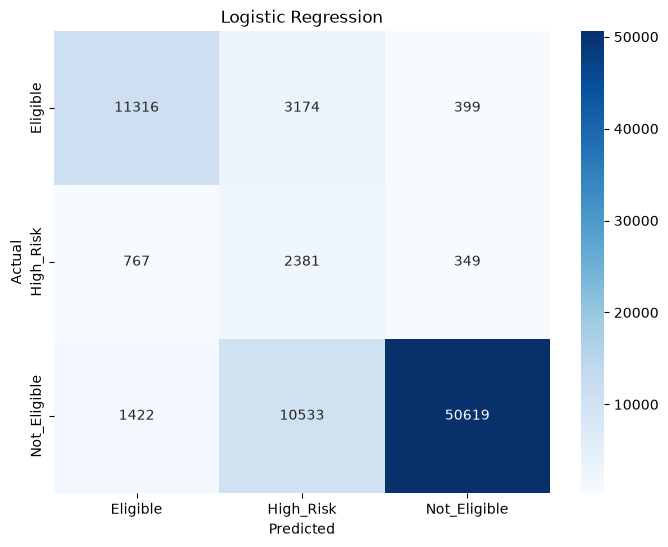

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

## Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
rf_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

## Fit

In [18]:
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['age','gender','marital_status',...,'employment_stability', 'loan_burden_ratio','available_income']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

## Predict

In [19]:
rf_pred = rf_model.predict(
    X_test
)

## Metrics

In [20]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

rf_prec = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_rec = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("Accuracy :", rf_acc)
print("Precision:", rf_prec)
print("Recall   :", rf_rec)
print("F1 Score :", rf_f1)

Accuracy : 0.8782485177865612
Precision: 0.9393095908473771
Recall   : 0.8782485177865612
F1 Score : 0.9020263881698908


## Classification Report

In [21]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    Eligible       0.88      0.84      0.86     14889
   High_Risk       0.24      0.70      0.36      3497
Not_Eligible       0.99      0.90      0.94     62574

    accuracy                           0.88     80960
   macro avg       0.70      0.81      0.72     80960
weighted avg       0.94      0.88      0.90     80960



## Confusion Matrix

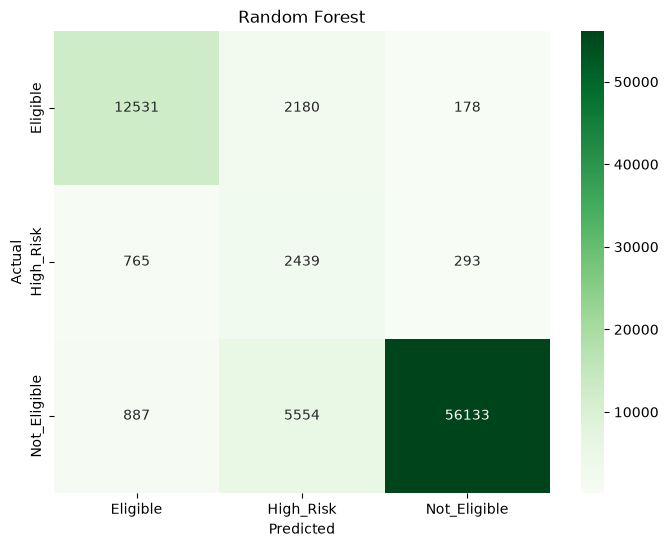

In [22]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# XGBoost Classifier

In [24]:
from xgboost import XGBClassifier
print(le.classes_)

['Eligible' 'High_Risk' 'Not_Eligible']


In [25]:
xgb_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        )
    )
])

## Train

In [26]:
xgb_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['age','gender','marital_status',...,'employment_stability', 'loan_burden_ratio','available_income']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

## Predict

In [27]:
xgb_pred = xgb_model.predict(X_test)

## Metric

In [28]:
xgb_acc = accuracy_score(y_test, xgb_pred)

xgb_prec = precision_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_rec = recall_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted"
)

print("Accuracy :", xgb_acc)
print("Precision:", xgb_prec)
print("Recall   :", xgb_rec)
print("F1 Score :", xgb_f1)

Accuracy : 0.9678606719367588
Precision: 0.9650193161393131
Recall   : 0.9678606719367588
F1 Score : 0.9630370289890685


## Classification Report

In [29]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    Eligible       0.94      0.98      0.96     14889
   High_Risk       0.84      0.40      0.54      3497
Not_Eligible       0.98      1.00      0.99     62574

    accuracy                           0.97     80960
   macro avg       0.92      0.79      0.83     80960
weighted avg       0.97      0.97      0.96     80960



In [32]:
import joblib

joblib.dump(
    xgb_model,
    "best_classifier.pkl"
)

joblib.dump(
    le,
    "label_encoder.pkl"
)

print("Classification model saved")

Classification model saved
